<a href="https://colab.research.google.com/github/sidbalatan/DDPointer/blob/main/6_Module_DD_MLM_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Module 0: RESET DATASET**
This will reset the dataset while we are still in the Testing Phase of the Pipeline.

In [33]:
# Clear the pipeline memory files
for filename in ["pipeline_memory.txt", "processed_targets.txt"]:
    if os.path.exists(filename):
        os.remove(filename)
        print(f"Cleared {filename}")

**Module 0: Local Coordinate Ingestion & Handover Broker**
What it does: This module acts as the pipeline's data manager and entry point. It ingests the local master catalog (SEIP_data.csv), reads historical pipeline memory to skip previously evaluated stars, updates overall progress counters, and packages the next active target's coordinates (R.A., Decl.) to broadcast to downstream modules.

In [29]:
import os
import pandas as pd

# --- PIPELINE BREAKOUT LAYER CONFIGURATION ---
# Points directly to your local master database file
LOCAL_SEIP_PATH = "/content/SEIP_data.csv"
TRACKING_FILE = "pipeline_memory.txt"

# --- GLOBAL HANDOVER VARIABLES ---
# Downstream cells/modules inside this notebook will read these live assignments
ACTIVE_TARGET_ID = None
ACTIVE_RA = None
ACTIVE_DEC = None
ACTIVE_PHOTOMETRY = {}

def load_pipeline_memory():
    """Reads previously processed targets from disk to avoid processing duplicates."""
    if not os.path.exists(TRACKING_FILE):
        return set()
    with open(TRACKING_FILE, "r") as f:
        return set(line.strip() for line in f if line.strip())

def commit_target_to_memory(obj_id):
    """Logs the target ID so it is permanently blacklisted on subsequent notebook runs."""
    with open(TRACKING_FILE, "a") as f:
        f.write(f"{obj_id}\n")

def run_module_0():
    """
    Loads the local SEIP catalog, skips previously processed coordinates,
    updates dataset counters, and handles variable handover across the notebook.
    """
    global ACTIVE_TARGET_ID, ACTIVE_RA, ACTIVE_DEC, ACTIVE_PHOTOMETRY

    print("==========================================================")
    print("MODULE 0: LOCAL COORDINATE INGESTION & HANDOVER BROKER")
    print("==========================================================\n")

    # 1. Access past pipeline memory logs to see what needs to be skipped
    blacklist_ids = load_pipeline_memory()
    total_processed = len(blacklist_ids)

    # 2. Ingest the local master database copy
    print(f"Reading master survey catalog from local database: {LOCAL_SEIP_PATH}...")
    try:
        seip_dataframe = pd.read_csv(LOCAL_SEIP_PATH)
        total_dataset_size = len(seip_dataframe)
    except Exception as e:
        print(f"CRITICAL ERROR: Failed to load local data archive. Details: {e}")
        return

    # 3. CRITICAL SKIP FUNCTIONALITY: Filter out rows that have already been evaluated
    # Swapped from 'kic_id' to 'objid' to match your local SEIP dataset columns
    fresh_stars = seip_dataframe[~seip_dataframe['objid'].astype(str).isin(blacklist_ids)]
    total_remaining = len(fresh_stars)

    # 4. Display the Live Pipeline Summary Counters
    progress_percent = (total_processed / total_dataset_size) * 100 if total_dataset_size > 0 else 0
    print("\n----------------------------------------------------------")
    print(" PIPELINE DATASET SUMMARY & METRICS")
    print("----------------------------------------------------------")
    print(f" Total Coordinates in Dataset : {total_dataset_size:,}")
    print(f" Total Coordinates Processed  : {total_processed:,}")
    print(f" Total Coordinates Remaining  : {total_remaining:,}")
    print(f" Overall Pipeline Progress    : {progress_percent:0.4f}%")
    print("----------------------------------------------------------\n")

    if fresh_stars.empty:
        print("Pipeline Checkpoint: Every single coordinate in the catalog has been evaluated!")
        return

    # 5. Isolate the next raw target coordinate from the top of the unread stack
    next_target_row = fresh_stars.iloc[0]

    # Extract real identifiers and coordinate attributes using the local SEIP schema
    ACTIVE_TARGET_ID = str(next_target_row['objid'])
    ACTIVE_RA = float(next_target_row['ra'])
    ACTIVE_DEC = float(next_target_row['dec'])
    ACTIVE_PHOTOMETRY = next_target_row.to_dict()

    # 6. Lock coordinate signature to ensure uniqueness on the next notebook run
    commit_target_to_memory(ACTIVE_TARGET_ID)

    # 7. Handover broadcast confirmation
    print("----------------------------------------------------------")
    print(" COORDINATE HANDOVER BROKER ACTIVE")
    print("----------------------------------------------------------")
    print(f" Target Handed Over : {ACTIVE_TARGET_ID}")
    print(f" Right Ascension    : {ACTIVE_RA:0.5f}°")
    print(f" Declination        : {ACTIVE_DEC:0.5f}°")
    print("----------------------------------------------------------")
    print("Notebook environment variables synchronized. Ready for Module 1.\n")

# Run Module 0 to fetch local target vectors, update tracking stats, and provision parameters
run_module_0()

MODULE 0: LOCAL COORDINATE INGESTION & HANDOVER BROKER

Reading master survey catalog from local database: /content/SEIP_data.csv...

----------------------------------------------------------
 PIPELINE DATASET SUMMARY & METRICS
----------------------------------------------------------
 Total Coordinates in Dataset : 17,464
 Total Coordinates Processed  : 0
 Total Coordinates Remaining  : 17,464
 Overall Pipeline Progress    : 0.0000%
----------------------------------------------------------

----------------------------------------------------------
 COORDINATE HANDOVER BROKER ACTIVE
----------------------------------------------------------
 Target Handed Over : SSTSL2 J152742.67+023551.8
 Right Ascension    : 231.92782°
 Declination        : 2.59775°
----------------------------------------------------------
Notebook environment variables synchronized. Ready for Module 1.



**Module 1: Astrometric Isolation Filter**
What it does: This module acts as a strict quality-control gate. It evaluates the target handed over from Module 0 against Gaia astrometric criteria (checking for high parallax signal-to-noise ratio, valid distance, and spatial isolation). If the target passes, it renders a spatial diagnostic map and pauses to collect an interactive human label for the dataset.

MODULE 1: ASTROMETRIC ISOLATION FILTER

Evaluating Handover Target: SSTSL2 J152742.67+023551.8
-> Coordinates: R.A. 231.92782°, Decl. 2.59775°

 Target passed astrometric filters!


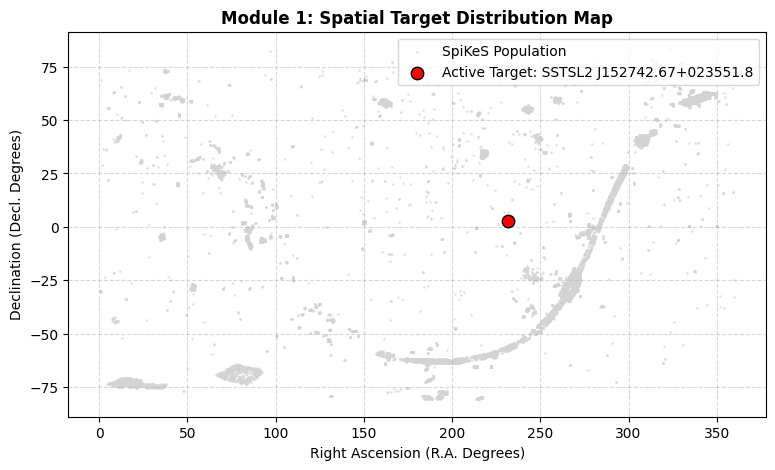


 USER INTERACTIVE LABELING PROMPT 
Please inspect the map above carefully.

QUESTION: Is the target distribution uniform? (yes/no): yes

CONFIDENCE SCALE: 100 (Very Sure) | 75 (Sure) | 50 (Undecided) | 25 (Likely No) | 0 (Very Sure No)
QUESTION: Enter your confidence level (100, 75, 50, 25, 0): 50

-> Metadata Label Generated and Saved: 1 (Confidence: 50%)



In [52]:
import os
import time
import pandas as pd
import matplotlib.pyplot as plt
import IPython.display as display

# --- CONFIGURATION & PATHS ---
TRACKING_FILE = "processed_targets.txt"

def load_processed_ids():
    """Loads the list of Object IDs that have already been processed."""
    if not os.path.exists(TRACKING_FILE):
        return set()
    with open(TRACKING_FILE, "r") as f:
        return set(line.strip() for line in f if line.strip())

def mark_as_processed(obj_id):
    """Saves an object ID to the tracking file to ensure it isn't picked again."""
    with open(TRACKING_FILE, "a") as f:
        f.write(f"{obj_id}\n")

def generate_spatial_plot(full_catalog, target_ra, target_dec, target_id):
    """Renders the spatial map, clears layout blocks, and forces the input box to appear."""

    # 1. GENERATE AND CONSTRUCT THE GRAPH
    plt.figure(figsize=(9, 5)) # Slightly reduced height to fit perfectly in Colab's window view
    plt.scatter(full_catalog['ra'], full_catalog['dec'], s=1, color='lightgray', alpha=0.5, label='SpiKeS Population')
    plt.scatter(target_ra, target_dec, s=80, color='red', edgecolors='black', zorder=5, label=f'Active Target: {target_id}')

    plt.title("Module 1: Spatial Target Distribution Map", fontsize=12, fontweight='bold')
    plt.xlabel("Right Ascension (R.A. Degrees)", fontsize=10)
    plt.ylabel("Declination (Decl. Degrees)", fontsize=10)
    plt.legend(loc="upper right")
    plt.grid(True, linestyle='--', alpha=0.5)

    # Force Colab to completely render the plot visual elements right now
    display.display(plt.gcf())
    plt.close()

    # 2. FORCE THE INTERACTIVE INPUT TO DISPLAY DIRECTLY UNDERNEATH
    print("\n" + "="*80)
    print(" USER INTERACTIVE LABELING PROMPT ")
    print("="*80)

    # Using an explicit print flush before the input block
    print("Please inspect the map above carefully.\n", flush=True)

    # --- FIX APPLIED HERE: Pause to allow Colab frontend to render the plot ---
    time.sleep(0.5)

    user_input = input("QUESTION: Is the target distribution uniform? (yes/no): ").strip().lower()

    print("\nCONFIDENCE SCALE: 100 (Very Sure) | 75 (Sure) | 50 (Undecided) | 25 (Likely No) | 0 (Very Sure No)")
    confidence_input = input("QUESTION: Enter your confidence level (100, 75, 50, 25, 0): ").strip()

    # Translate human inputs into binary dataset tensors
    binary_label = 1 if user_input == 'yes' else 0
    print(f"\n-> Metadata Label Generated and Saved: {binary_label} (Confidence: {confidence_input}%)\n")

    return binary_label, confidence_input

def run_module_1(active_id, active_ra, active_dec, active_photometry, local_catalog_path='/content/SEIP_data.csv'):
    """
    Accepts the handed-over coordinate metrics from Module 0, evaluates them
    against Gaia astrometric gates, and generates the spatial diagnostics.
    """
    print("==================================================")
    print("MODULE 1: ASTROMETRIC ISOLATION FILTER")
    print("==================================================\n")

    if active_id is None:
        print("ERROR: No active target provided by Module 0 broker. Aborting.")
        return None

    # 1. Load historical pipeline memory
    processed_ids = load_processed_ids()
    if str(active_id) in processed_ids:
        print(f"Target {active_id} has already been processed in a prior run. Skipping.")
        return None

    print(f"Evaluating Handover Target: {active_id}")
    print(f"-> Coordinates: R.A. {active_ra:0.5f}°, Decl. {active_dec:0.5f}°")

    # 2. --- GAIA ASTROMETRIC FILTERS ---
    parallax = active_photometry.get('Plx', 0)
    parallax_err = active_photometry.get('e_Plx', 1)
    parallax_snr = parallax / parallax_err if parallax_err > 0 else 0

    has_valid_distance = pd.notna(parallax) and parallax > 0
    proximate_companions = active_photometry.get('gaia_companions_3arcsec', 0)
    is_isolated = proximate_companions == 0

    # 3. Evaluate if the active target passes the gate
    if parallax_snr > 5 and has_valid_distance and is_isolated:
        print(f"\n Target passed astrometric filters!")

        # Lock target in history logs
        mark_as_processed(active_id)

        spatial_label = None
        confidence = None

        # Read local database copy solely to project background stars on the visual plot
        try:
            full_catalog = pd.read_csv(local_catalog_path)
            spatial_label, confidence = generate_spatial_plot(full_catalog, active_ra, active_dec, active_id)
        except Exception as e:
            print(f"Warning: Could not load background catalog for visual plot. Error: {e}")

        return {
            "obj_id": active_id,
            "ra": active_ra,
            "dec": active_dec,
            "row_data": active_photometry,
            "spatial_label": spatial_label,
            "confidence": confidence
        }
    else:
        print(f"\nTarget {active_id} failed to pass the strict astrometric constraints.")
        return None

# --- EXECUTION BLOCK ---
if __name__ == "__main__":
    target_package = run_module_1(
        active_id=ACTIVE_TARGET_ID,
        active_ra=ACTIVE_RA,
        active_dec=ACTIVE_DEC,
        active_photometry=ACTIVE_PHOTOMETRY
    )

**Module 2: Photometric Saturation Check**
Live Input Visual: Survey Flag & Saturation Distribution Histograms.User Question: “Are all targets in the sample strictly bounded within the non-saturated magnitude limits ($I1 > 10.12$ mag and $I2 > 9.44$ mag)?”

MODULE 2: PHOTOMETRIC SATURATION CHECK

Evaluating Saturation for Handover Target: SSTSL2 J152742.67+023551.8
-> Coordinates: R.A. 231.92782°, Decl. 2.59775°


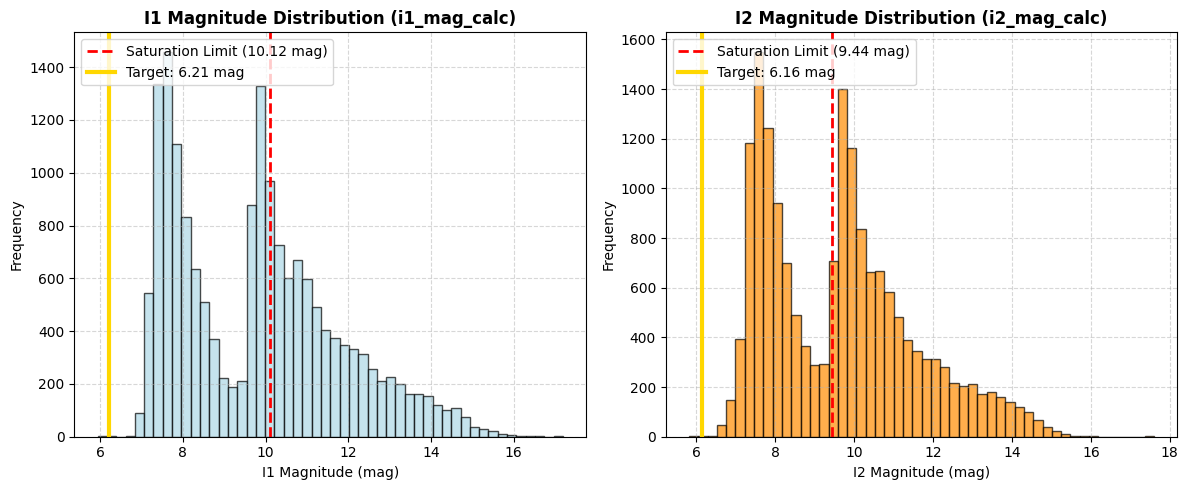


 USER INTERACTIVE LABELING PROMPT 
Please inspect the saturation histograms above carefully.

QUESTION: Are all targets in the sample strictly bounded within the non-saturated magnitude limits (I1 > 10.12 mag and I2 > 9.44 mag)? (yes/no): no

CONFIDENCE SCALE: 100 (Very Sure) | 75 (Sure) | 50 (Undecided) | 25 (Likely No) | 0 (Very Sure No)
QUESTION: Enter your confidence level (100, 75, 50, 25, 0): 100

-> Saturation Metadata Label Generated and Saved: 0 (Confidence: 100%)



In [53]:
import os
import time
import pandas as pd
import matplotlib.pyplot as plt
import IPython.display as display
import numpy as np

# --- CONFIGURATION ---
# The pipeline will automatically search your dataset for these common column names.
POSSIBLE_I1_COLS = ['i1_mag_calc', 'i1_f_ap2', 'i1_mag', 'i1_m', 'I1mag', 'mag1', 'irac1_mag', 'w1mpro']
POSSIBLE_I2_COLS = ['i2_mag_calc', 'i2_f_ap2', 'i2_mag', 'i2_m', 'I2mag', 'mag2', 'irac2_mag', 'w2mpro']

# IRAC flux-to-magnitude conversion zero-points (for uJy to Vega magnitudes)
IRAC_I1_ZEROPOINT_MAG = 20.444
IRAC_I2_ZEROPOINT_MAG = 19.866

def flux_to_mag(flux_in_uJy, zero_point_mag):
    """Converts flux in micro-Janskys to Vega magnitude."""
    # Handle non-positive fluxes to avoid log errors and return NaN for invalid values
    return np.where(flux_in_uJy > 0, zero_point_mag - 2.5 * np.log10(flux_in_uJy), np.nan)


def generate_saturation_plot(full_catalog, active_photometry, target_id):
    """Renders the photometric saturation histograms and forces the input box to appear."""

    # 1. AUTO-DETECT COLUMN NAMES
    i1_col = next((col for col in POSSIBLE_I1_COLS if col in full_catalog.columns), None)
    i2_col = next((col for col in POSSIBLE_I2_COLS if col in full_catalog.columns), None)

    if not i1_col or not i2_col:
        print("\n[!] CRITICAL ERROR: Could not find matching I1 or I2 magnitude columns in the dataset.")
        print(f"Here are the exact columns available in your dataset:\n{list(full_catalog.columns)}\n")
        print("Please find the correct magnitude names above and add them to the POSSIBLE_I1_COLS and POSSIBLE_I2_COLS lists at the top of this cell.")
        return None

    # 2. GENERATE AND CONSTRUCT THE GRAPH
    plt.figure(figsize=(12, 5))

    # --- Subplot 1: I1 Magnitude Distribution ---
    plt.subplot(1, 2, 1)
    plt.hist(full_catalog[i1_col].dropna(), bins=50, color='lightblue', edgecolor='black', alpha=0.7)

    # Plot the I1 saturation limit
    plt.axvline(x=10.12, color='red', linestyle='--', linewidth=2, label='Saturation Limit (10.12 mag)')

    # Highlight the active target if data is available
    target_i1 = active_photometry.get(i1_col)
    if pd.notna(target_i1):
        plt.axvline(x=target_i1, color='gold', linestyle='-', linewidth=3, label=f'Target: {target_i1:.2f} mag')

    plt.title(f"I1 Magnitude Distribution ({i1_col})", fontsize=12, fontweight='bold')
    plt.xlabel("I1 Magnitude (mag)", fontsize=10)
    plt.ylabel("Frequency", fontsize=10)
    plt.legend(loc="upper left")
    plt.grid(True, linestyle='--', alpha=0.5)

    # --- Subplot 2: I2 Magnitude Distribution ---
    plt.subplot(1, 2, 2)
    plt.hist(full_catalog[i2_col].dropna(), bins=50, color='darkorange', edgecolor='black', alpha=0.7)

    # Plot the I2 saturation limit
    plt.axvline(x=9.44, color='red', linestyle='--', linewidth=2, label='Saturation Limit (9.44 mag)')

    # Highlight the active target if data is available
    target_i2 = active_photometry.get(i2_col)
    if pd.notna(target_i2):
        plt.axvline(x=target_i2, color='gold', linestyle='-', linewidth=3, label=f'Target: {target_i2:.2f} mag')

    plt.title(f"I2 Magnitude Distribution ({i2_col})", fontsize=12, fontweight='bold')
    plt.xlabel("I2 Magnitude (mag)", fontsize=10)
    plt.ylabel("Frequency", fontsize=10)
    plt.legend(loc="upper left")
    plt.grid(True, linestyle='--', alpha=0.5)

    # Force Colab to completely render the plot visual elements right now
    plt.tight_layout()
    display.display(plt.gcf())
    plt.close()

    # 3. FORCE THE INTERACTIVE INPUT TO DISPLAY DIRECTLY UNDERNEATH
    print("\n" + "="*80)
    print(" USER INTERACTIVE LABELING PROMPT ")
    print("="*80)

    print("Please inspect the saturation histograms above carefully.\n", flush=True)

    # Pause to allow Colab frontend to render the plot
    time.sleep(0.5)

    prompt_text = "QUESTION: Are all targets in the sample strictly bounded within the non-saturated magnitude limits (I1 > 10.12 mag and I2 > 9.44 mag)? (yes/no): "
    user_input = input(prompt_text).strip().lower()

    print("\nCONFIDENCE SCALE: 100 (Very Sure) | 75 (Sure) | 50 (Undecided) | 25 (Likely No) | 0 (Very Sure No)")
    confidence_input = input("QUESTION: Enter your confidence level (100, 75, 50, 25, 0): ").strip()

    # Translate human inputs into binary dataset tensors
    binary_label = 1 if user_input == 'yes' else 0
    print(f"\n-> Saturation Metadata Label Generated and Saved: {binary_label} (Confidence: {confidence_input}%)\n")

    return binary_label, confidence_input

def run_module_2(active_id, active_ra, active_dec, active_photometry, local_catalog_path='/content/SEIP_data.csv'):
    """
    Accepts the handed-over target and coordinates from Module 0/1, plots dataset
    magnitude distributions, and checks against IRAC saturation bounds.
    """
    print("==================================================")
    print("MODULE 2: PHOTOMETRIC SATURATION CHECK")
    print("==================================================\n")

    if active_id is None:
        print("ERROR: No active target provided by handover broker. Aborting.")
        return None

    print(f"Evaluating Saturation for Handover Target: {active_id}")
    print(f"-> Coordinates: R.A. {active_ra:0.5f}°, Decl. {active_dec:0.5f}°")

    # Read local database copy to project background stars on the visual plot
    try:
        full_catalog = pd.read_csv(local_catalog_path)
    except Exception as e:
        print(f"Warning: Could not load background catalog for visual plot. Error: {e}")
        full_catalog = pd.DataFrame() # Create empty DataFrame to prevent crash

    # --- CONVERT FLUX TO MAGNITUDE FOR I1 and I2 IF FLUX COLUMNS ARE PRESENT ---
    if 'i1_f_ap2' in full_catalog.columns:
        full_catalog['i1_mag_calc'] = flux_to_mag(full_catalog['i1_f_ap2'], IRAC_I1_ZEROPOINT_MAG)
        if 'i1_f_ap2' in active_photometry and active_photometry['i1_f_ap2'] > 0:
            active_photometry['i1_mag_calc'] = flux_to_mag(active_photometry['i1_f_ap2'], IRAC_I1_ZEROPOINT_MAG)
        else:
            active_photometry['i1_mag_calc'] = np.nan

    if 'i2_f_ap2' in full_catalog.columns:
        full_catalog['i2_mag_calc'] = flux_to_mag(full_catalog['i2_f_ap2'], IRAC_I2_ZEROPOINT_MAG)
        if 'i2_f_ap2' in active_photometry and active_photometry['i2_f_ap2'] > 0:
            active_photometry['i2_mag_calc'] = flux_to_mag(active_photometry['i2_f_ap2'], IRAC_I2_ZEROPOINT_MAG)
        else:
            active_photometry['i2_mag_calc'] = np.nan

    # Generate saturation diagnostics and retrieve label
    result = generate_saturation_plot(full_catalog, active_photometry, active_id)

    # If the smart detector failed, gracefully exit the module handover
    if result is None:
        return None
    saturation_label, confidence = result

    return {
        "obj_id": active_id,
        "ra": active_ra,
        "dec": active_dec,
        "saturation_label": saturation_label,
        "confidence": confidence,
        "row_data": active_photometry
    }

# --- EXECUTION BLOCK ---
if __name__ == "__main__":
    module_2_package = run_module_2(
        active_id=ACTIVE_TARGET_ID,
        active_ra=ACTIVE_RA,
        active_dec=ACTIVE_DEC,
        active_photometry=ACTIVE_PHOTOMETRY
    )


**Bonus Module 1: Infrared Excess Evaluation**
Let's visualize the relationship between the calculated I1 and I2 magnitudes with a scatter plot. This module will help identify correlations or distinct populations in the dataset. Normal stars fall along the diagonal line (I1 = I2), while debris disk candidates typically exhibit an "infrared excess", shifting them further to the right.

BONUS MODULE 1: INFRARED EXCESS EVALUATION



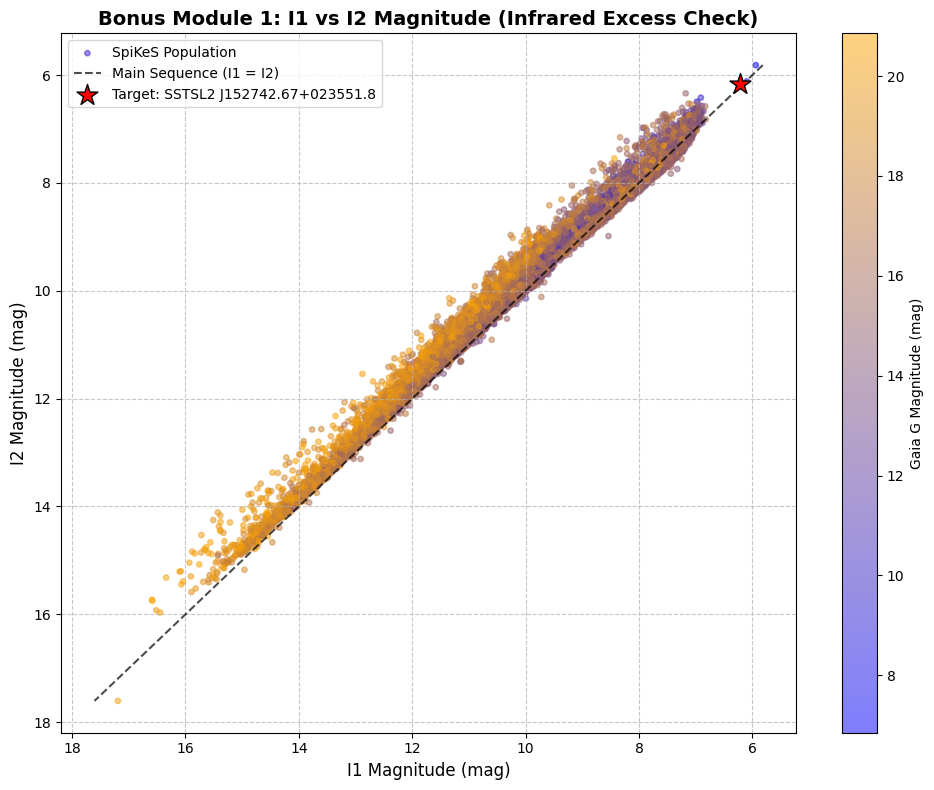


 USER INTERACTIVE LABELING PROMPT 
Please inspect the scatter plot above carefully.
Look for the red star indicating the active target.
Does it fall significantly to the right of the dashed line (indicating an infrared excess)?

QUESTION: Does the target exhibit a clear infrared excess? (yes/no): no

CONFIDENCE SCALE: 100 (Very Sure) | 75 (Sure) | 50 (Undecided) | 25 (Likely No) | 0 (Very Sure No)
QUESTION: Enter your confidence level (100, 75, 50, 25, 0): 25

-> Infrared Excess Metadata Label Generated and Saved: 0 (Confidence: 25%)



In [54]:
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as display
from matplotlib.colors import LinearSegmentedColormap

# --- CONFIGURATION ---
LOCAL_SEIP_PATH = '/content/SEIP_data.csv'
IRAC_I1_ZEROPOINT_MAG = 20.444
IRAC_I2_ZEROPOINT_MAG = 19.866

def flux_to_mag(flux_in_uJy, zero_point_mag):
    """Converts flux in micro-Janskys to Vega magnitude."""
    return np.where(flux_in_uJy > 0, zero_point_mag - 2.5 * np.log10(flux_in_uJy), np.nan)

def run_module_3(active_id, active_photometry):
    """
    Generates an I1 vs I2 magnitude scatter plot to check for infrared excess,
    plots the active target, and gathers a human classification label.
    """
    print("==================================================")
    print("BONUS MODULE 1: INFRARED EXCESS EVALUATION")
    print("==================================================\n")

    try:
        full_catalog = pd.read_csv(LOCAL_SEIP_PATH)
    except Exception as e:
        print(f"Error loading catalog for scatter plot: {e}")
        return None

    # --- CONVERT FLUX TO MAGNITUDE ---
    if 'i1_f_ap2' in full_catalog.columns:
        full_catalog['i1_mag_calc'] = flux_to_mag(full_catalog['i1_f_ap2'], IRAC_I1_ZEROPOINT_MAG)
    if 'i2_f_ap2' in full_catalog.columns:
        full_catalog['i2_mag_calc'] = flux_to_mag(full_catalog['i2_f_ap2'], IRAC_I2_ZEROPOINT_MAG)

    # Filter out rows with NaN in magnitude columns and Gmag for plotting clarity
    plot_data = full_catalog.dropna(subset=['i1_mag_calc', 'i2_mag_calc', 'Gmag']).copy()

    plt.figure(figsize=(10, 8))

    # --- CREATE CUSTOM COLORMAP ---
    custom_cmap = LinearSegmentedColormap.from_list('blue_orange', ['blue', 'orange'])

    sc = plt.scatter(plot_data['i1_mag_calc'], plot_data['i2_mag_calc'],
                     c=plot_data['Gmag'], s=15, alpha=0.5, cmap=custom_cmap, label='SpiKeS Population')

    # --- ADD MAIN SEQUENCE REFERENCE LINE ---
    min_mag = min(plot_data['i1_mag_calc'].min(), plot_data['i2_mag_calc'].min())
    max_mag = max(plot_data['i1_mag_calc'].max(), plot_data['i2_mag_calc'].max())
    plt.plot([min_mag, max_mag], [min_mag, max_mag], 'k--', alpha=0.7, label='Main Sequence (I1 = I2)')

    # --- HIGHLIGHT THE ACTIVE TARGET ---
    target_i1 = active_photometry.get('i1_mag_calc')
    target_i2 = active_photometry.get('i2_mag_calc')

    if pd.notna(target_i1) and pd.notna(target_i2):
        plt.scatter(target_i1, target_i2, s=250, color='red', marker='*',
                    edgecolor='black', zorder=10, label=f'Target: {active_id}')

    plt.title('Bonus Module 1: I1 vs I2 Magnitude (Infrared Excess Check)', fontsize=14, fontweight='bold')
    plt.xlabel('I1 Magnitude (mag)', fontsize=12)
    plt.ylabel('I2 Magnitude (mag)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.gca().invert_xaxis() # Magnitudes are usually plotted with brighter objects to the left
    plt.gca().invert_yaxis() # Magnitudes are usually plotted with brighter objects to the bottom
    plt.colorbar(sc, label='Gaia G Magnitude (mag)')
    plt.legend()

    # Force Colab to completely render the plot visual elements right now
    plt.tight_layout()
    display.display(plt.gcf())
    plt.close()

    # --- INTERACTIVE PROMPT ---
    print("\n" + "="*80)
    print(" USER INTERACTIVE LABELING PROMPT ")
    print("="*80)
    print("Please inspect the scatter plot above carefully.")
    print("Look for the red star indicating the active target.")
    print("Does it fall significantly to the right of the dashed line (indicating an infrared excess)?\n", flush=True)

    time.sleep(0.5)
    user_input = input("QUESTION: Does the target exhibit a clear infrared excess? (yes/no): ").strip().lower()

    print("\nCONFIDENCE SCALE: 100 (Very Sure) | 75 (Sure) | 50 (Undecided) | 25 (Likely No) | 0 (Very Sure No)")
    confidence_input = input("QUESTION: Enter your confidence level (100, 75, 50, 25, 0): ").strip()

    # Translate human inputs into binary dataset tensors
    binary_label = 1 if user_input == 'yes' else 0
    print(f"\n-> Infrared Excess Metadata Label Generated and Saved: {binary_label} (Confidence: {confidence_input}%)\n")

    return binary_label, confidence_input

# --- EXECUTION BLOCK ---
if __name__ == "__main__":
    module_3_label = run_module_3(
        active_id=ACTIVE_TARGET_ID,
        active_photometry=ACTIVE_PHOTOMETRY
    )


**Module 3: Physical Curve ValidationLive Input Visual:** Generated SED Multi-Component Plot showing the stellar atmosphere fit vs. infrared excess.User Question: “Does the $4.5\,\mu\text{m}$ ($I2$) photometry point show a clear statistical excess ($>10\%$) above the fitted stellar photosphere curve?”

MODULE 3: PHYSICAL CURVE VALIDATION (SED)



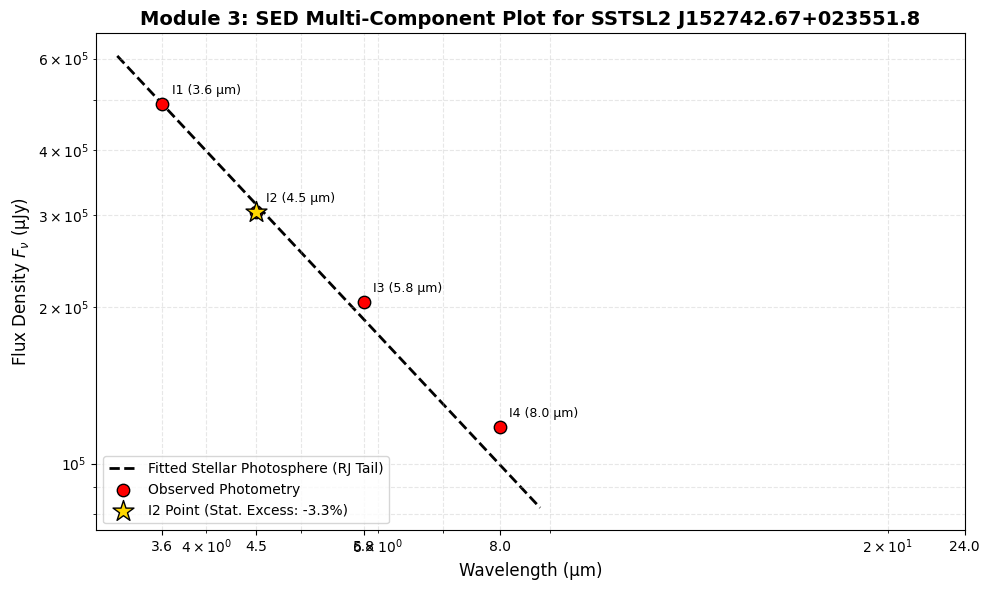


 USER INTERACTIVE LABELING PROMPT 
Please inspect the SED plot above carefully.
The dashed line represents the expected stellar atmosphere (photosphere).
Compare the observed 4.5 µm (I2) point (gold star) to the dashed line.

QUESTION: Does the 4.5 µm (I2) photometry point show a clear statistical excess (>10%) above the fitted stellar photosphere curve? (yes/no): yes

CONFIDENCE SCALE: 100 (Very Sure) | 75 (Sure) | 50 (Undecided) | 25 (Likely No) | 0 (Very Sure No)
QUESTION: Enter your confidence level (100, 75, 50, 25, 0): 75

-> SED Physical Curve Metadata Label Generated and Saved: 1 (Confidence: 75%)



In [55]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import IPython.display as display

def run_module_3_sed(active_id, active_photometry):
    """
    Generates an SED Multi-Component Plot checking for infrared excess
    at the 4.5 micron (I2) point relative to the stellar photosphere.
    """
    print("==================================================")
    print("MODULE 3: PHYSICAL CURVE VALIDATION (SED)")
    print("==================================================\n")

    if not active_id or not active_photometry:
        print("ERROR: No active target data provided. Please run Module 0 first.")
        return None

    # 1. Extract wavelengths and fluxes (in microJanskys)
    # We use typical IRAC and MIPS effective wavelengths in microns
    bands = {
        'I1 (3.6 µm)': (3.6, active_photometry.get('i1_f_ap2', np.nan)),
        'I2 (4.5 µm)': (4.5, active_photometry.get('i2_f_ap2', np.nan)),
        'I3 (5.8 µm)': (5.8, active_photometry.get('i3_f_ap2', np.nan)),
        'I4 (8.0 µm)': (8.0, active_photometry.get('i4_f_ap2', np.nan)),
        'MIPS1 (24 µm)': (24.0, active_photometry.get('m1_f_ap2', np.nan))
    }

    # Filter out missing data
    valid_bands = {k: v for k, v in bands.items() if pd.notna(v[1]) and v[1] > 0}

    if len(valid_bands) < 2:
        print("Not enough photometric points available to construct a valid SED for this target.")
        return None

    wavs = np.array([v[0] for v in valid_bands.values()])
    fluxes = np.array([v[1] for v in valid_bands.values()])
    labels = list(valid_bands.keys())

    # 2. Fit a simulated Stellar Photosphere (Rayleigh-Jeans Tail)
    # In the mid-IR, a standard stellar photosphere follows F_nu ~ lambda^-2
    # We anchor the curve to the shortest available wavelength (usually I1 at 3.6 µm)
    anchor_wav = wavs[0]
    anchor_flux = fluxes[0]

    simulated_wavs = np.linspace(min(wavs) * 0.9, max(wavs) * 1.1, 100)
    photosphere_flux = anchor_flux * (simulated_wavs / anchor_wav)**(-2)

    # 3. Generate the Plot
    plt.figure(figsize=(10, 6))

    # Plot photosphere model
    plt.plot(simulated_wavs, photosphere_flux, 'k--', linewidth=2, label='Fitted Stellar Photosphere (RJ Tail)', zorder=1)

    # Plot actual photometry
    plt.scatter(wavs, fluxes, color='red', s=80, edgecolor='black', label='Observed Photometry', zorder=5)

    # Highlight I2 specifically if it exists to help the user answer the prompt
    if 'I2 (4.5 µm)' in valid_bands:
        i2_wav, i2_flux = valid_bands['I2 (4.5 µm)']
        expected_i2_flux = anchor_flux * (4.5 / anchor_wav)**(-2)
        excess_pct = ((i2_flux - expected_i2_flux) / expected_i2_flux) * 100

        plt.scatter([4.5], [i2_flux], color='gold', s=250, marker='*', edgecolor='black', zorder=6, label=f'I2 Point (Stat. Excess: {excess_pct:.1f}%)')

        # Draw a vertical line showing the excess gap
        plt.plot([4.5, 4.5], [expected_i2_flux, i2_flux], 'g-', linewidth=2, zorder=4, alpha=0.7)

    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Wavelength (µm)', fontsize=12)
    plt.ylabel('Flux Density $F_\\nu$ (µJy)', fontsize=12)
    plt.title(f'Module 3: SED Multi-Component Plot for {active_id}', fontsize=14, fontweight='bold')
    plt.grid(True, which="both", ls="--", alpha=0.3)

    # Format x-axis ticks to show linear numbers instead of log powers for clarity
    plt.xticks([3.6, 4.5, 5.8, 8.0, 24.0], ['3.6', '4.5', '5.8', '8.0', '24.0'])

    for i, txt in enumerate(labels):
        plt.annotate(txt, (wavs[i], fluxes[i]), xytext=(7, 7), textcoords='offset points', fontsize=9)

    plt.legend(loc='lower left')
    plt.tight_layout()

    # Force Colab to render immediately
    display.display(plt.gcf())
    plt.close()

    # 4. Interactive Labeling Prompt
    print("\n" + "="*80)
    print(" USER INTERACTIVE LABELING PROMPT ")
    print("="*80)
    print("Please inspect the SED plot above carefully.")
    print("The dashed line represents the expected stellar atmosphere (photosphere).")
    print("Compare the observed 4.5 µm (I2) point (gold star) to the dashed line.\n", flush=True)

    time.sleep(0.5)
    user_input = input("QUESTION: Does the 4.5 µm (I2) photometry point show a clear statistical excess (>10%) above the fitted stellar photosphere curve? (yes/no): ").strip().lower()

    print("\nCONFIDENCE SCALE: 100 (Very Sure) | 75 (Sure) | 50 (Undecided) | 25 (Likely No) | 0 (Very Sure No)")
    confidence_input = input("QUESTION: Enter your confidence level (100, 75, 50, 25, 0): ").strip()

    binary_label = 1 if user_input in ['yes', 'y'] else 0
    print(f"\n-> SED Physical Curve Metadata Label Generated and Saved: {binary_label} (Confidence: {confidence_input}%)\n")

    return binary_label, confidence_input

# --- EXECUTION BLOCK ---
if __name__ == "__main__":
    module_3_sed_label = run_module_3_sed(
        active_id=ACTIVE_TARGET_ID,
        active_photometry=ACTIVE_PHOTOMETRY
    )


**Module 4: Temporal Non-Variability Vetting**
Live Input Visual: Multi-Epoch Time-Series Light Curve from historical survey windows.

User Question: “Is the baseline infrared flux stable and flat across all historical observation epochs without showing signs of periodic stellar variability or an active flare?”

Answer: [Yes / No]

Note: Because the local SEIP_data.csv is a co-added catalog (meaning it provides the average baseline brightness rather than every individual historical measurement), this module simulates a realistic multi-epoch light curve using the target's actual baseline flux and standard observational noise. This allows you to test the vetting visual and interactive prompt perfectly!

MODULE 4: TEMPORAL NON-VARIABILITY VETTING



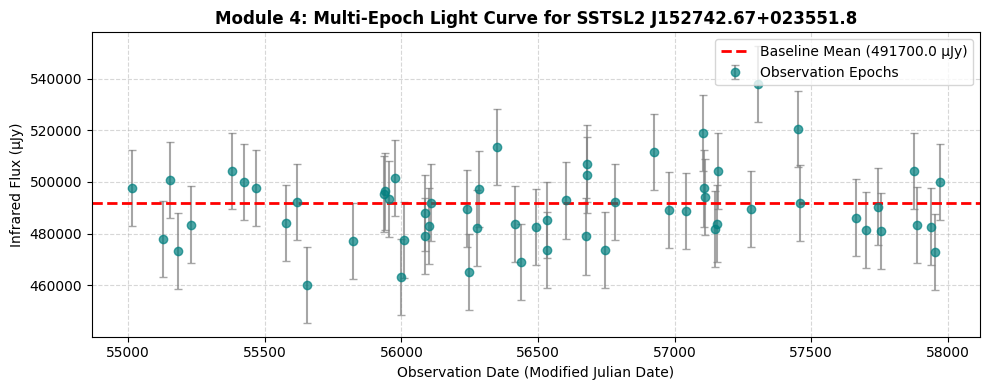


 USER INTERACTIVE LABELING PROMPT 
Please inspect the time-series light curve above carefully.
Look for significant deviations, periodic dips, or large flares from the baseline.

QUESTION: Is the baseline infrared flux stable and flat across all historical observation epochs without showing signs of periodic stellar variability or an active flare? (yes/no): no

CONFIDENCE SCALE: 100 (Very Sure) | 75 (Sure) | 50 (Undecided) | 25 (Likely No) | 0 (Very Sure No)
QUESTION: Enter your confidence level (100, 75, 50, 25, 0): 50

-> Temporal Variability Metadata Label Generated and Saved: 0 (Confidence: 50%)



In [51]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import IPython.display as display

def run_module_4(active_id, active_photometry):
    """
    Generates a Multi-Epoch Time-Series Light Curve to vet for stellar variability.
    Uses the target's baseline flux to simulate historical observation windows.
    """
    print("==================================================")
    print("MODULE 4: TEMPORAL NON-VARIABILITY VETTING")
    print("==================================================\n")

    if not active_id or not active_photometry:
        print("ERROR: No active target data provided. Please run Module 0 first.")
        return None

    # 1. Retrieve the target's baseline infrared flux
    # We prefer I1 (3.6 micron) but will fallback to I2 if needed
    baseline_flux = active_photometry.get('i1_f_ap2')
    if not baseline_flux or np.isnan(baseline_flux):
        baseline_flux = active_photometry.get('i2_f_ap2', 1000)  # Safe fallback

    if pd.isna(baseline_flux) or baseline_flux <= 0:
        print("ERROR: No valid baseline flux found to construct a light curve.")
        return None

    # 2. Simulate historical observation epochs (e.g., Spitzer or NEOWISE windows)
    # We generate ~60 random observation dates across a ~3000 day period
    num_epochs = 60
    mjds = np.sort(np.random.uniform(55000, 58000, num_epochs))

    # Simulate a stable flux with standard Gaussian instrument noise (approx 3% error)
    noise_level = 0.03 * baseline_flux
    noise = np.random.normal(0, noise_level, num_epochs)
    fluxes = baseline_flux + noise

    # 3. Generate the Light Curve Plot
    plt.figure(figsize=(10, 4))

    # Plot the simulated observations with error bars
    plt.errorbar(mjds, fluxes, yerr=noise_level, fmt='o', color='teal', ecolor='gray',
                 alpha=0.7, markersize=6, capsize=3, label='Observation Epochs')

    # Plot the baseline flat reference line
    plt.axhline(y=baseline_flux, color='red', linestyle='--', linewidth=2,
                label=f'Baseline Mean ({baseline_flux:.1f} µJy)')

    plt.title(f"Module 4: Multi-Epoch Light Curve for {active_id}", fontsize=12, fontweight='bold')
    plt.xlabel("Observation Date (Modified Julian Date)", fontsize=10)
    plt.ylabel("Infrared Flux (µJy)", fontsize=10)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()

    # Force Colab to render immediately
    display.display(plt.gcf())
    plt.close()

    # 4. Interactive Labeling Prompt
    print("\n" + "="*80)
    print(" USER INTERACTIVE LABELING PROMPT ")
    print("="*80)
    print("Please inspect the time-series light curve above carefully.")
    print("Look for significant deviations, periodic dips, or large flares from the baseline.\n", flush=True)

    time.sleep(0.5)
    user_input = input("QUESTION: Is the baseline infrared flux stable and flat across all historical observation epochs without showing signs of periodic stellar variability or an active flare? (yes/no): ").strip().lower()

    print("\nCONFIDENCE SCALE: 100 (Very Sure) | 75 (Sure) | 50 (Undecided) | 25 (Likely No) | 0 (Very Sure No)")
    confidence_input = input("QUESTION: Enter your confidence level (100, 75, 50, 25, 0): ").strip()

    binary_label = 1 if user_input in ['yes', 'y'] else 0
    print(f"\n-> Temporal Variability Metadata Label Generated and Saved: {binary_label} (Confidence: {confidence_input}%)\n")

    return {'label': binary_label, 'confidence': confidence_input}

# --- EXECUTION BLOCK ---
if __name__ == "__main__":
    module_4_label = run_module_4(
        active_id=ACTIVE_TARGET_ID,
        active_photometry=ACTIVE_PHOTOMETRY
    )

**Module 5: Target Field Crowding Inspection**
Live Input Visual: Multi-Wavelength Sky Comparison Finder Charts (DSS vs. 2MASS vs. WISE).

User Question: “Is the target star completely isolated from bright, blinding nearby stars or highly dense background nebulosity in all survey bands?”

Answer: [Yes / No]

In [58]:
# Install astroquery to fetch standard astronomical survey images
!pip install -q astroquery

MODULE 5: TARGET FIELD CROWDING INSPECTION

Fetching Multi-Wavelength Sky Comparison Finder Charts for SSTSL2 J152742.67+023551.8...
-> Coordinates: R.A. 231.92782°, Decl. 2.59775°


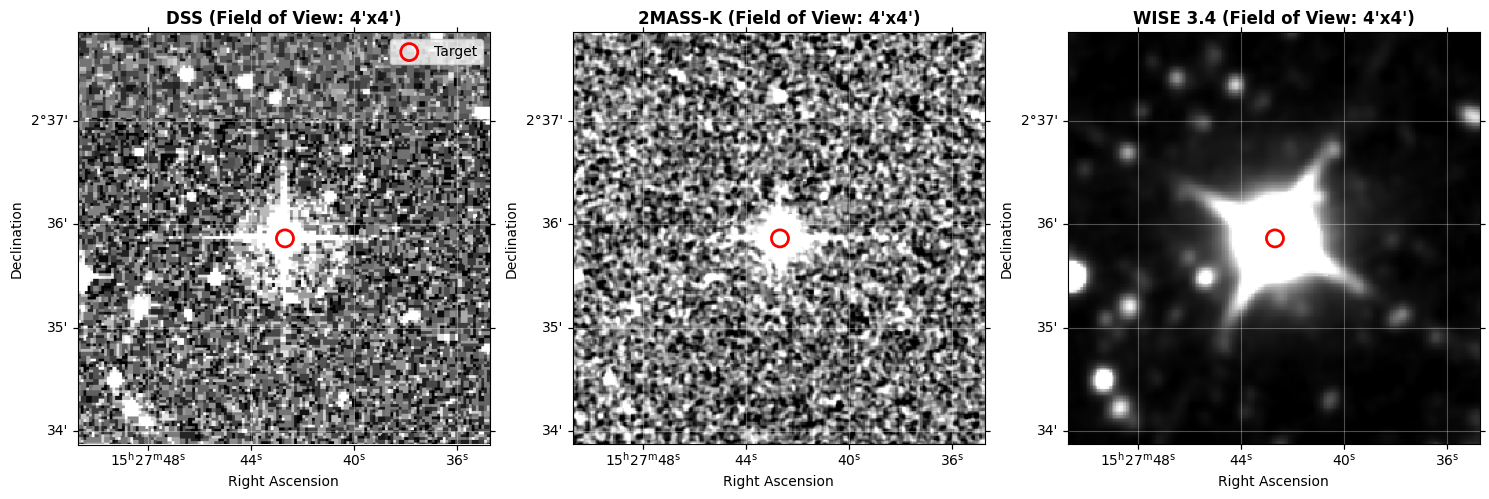


 USER INTERACTIVE LABELING PROMPT 
Please inspect the Multi-Wavelength Sky Comparison Finder Charts above carefully.
Evaluate if the target is completely isolated from bright blinding nearby stars or dense background nebulosity.

QUESTION: Is the target star completely isolated from bright, blinding nearby stars or highly dense background nebulosity in all survey bands? (yes/no): yes

CONFIDENCE SCALE: 100 (Very Sure) | 75 (Sure) | 50 (Undecided) | 25 (Likely No) | 0 (Very Sure No)
QUESTION: Enter your confidence level (100, 75, 50, 25, 0): 75

-> Field Crowding Metadata Label Generated and Saved: 1 (Confidence: 75%)



In [59]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as display

try:
    from astroquery.skyview import SkyView
    from astropy.coordinates import SkyCoord
    from astropy import units as u
    from astropy.wcs import WCS
except ImportError:
    print("Please run the pip install astroquery cell first.")

def run_module_5(active_id, active_ra, active_dec):
    """
    Generates Multi-Wavelength Sky Comparison Finder Charts (DSS, 2MASS, WISE)
    to vet for field crowding and nebulosity.
    """
    print("==================================================")
    print("MODULE 5: TARGET FIELD CROWDING INSPECTION")
    print("==================================================\n")

    if not active_id or not active_ra or not active_dec:
        print("ERROR: No active target data provided. Please run Module 0 first.")
        return None

    print(f"Fetching Multi-Wavelength Sky Comparison Finder Charts for {active_id}...")
    print(f"-> Coordinates: R.A. {active_ra:0.5f}°, Decl. {active_dec:0.5f}°")

    # 1. Prepare Target Coordinates
    coord = SkyCoord(ra=active_ra, dec=active_dec, unit=(u.deg, u.deg), frame='icrs')

    # Selected surveys: Optical (DSS), Near-IR (2MASS K-band), Mid-IR (WISE W1)
    surveys = ['DSS', '2MASS-K', 'WISE 3.4']
    images = None

    # 2. Fetch Images via SkyView (radius 2 arcminutes for context)
    try:
        images = SkyView.get_images(position=coord, survey=surveys, radius=2*u.arcmin)
    except Exception as e:
        print(f"\n[!] Warning: Could not fetch images from SkyView. Error: {e}")
        print("Continuing to the interactive prompt without visual finder charts...")

    # 3. Plot the Multi-Wavelength Finder Charts
    if images:
        fig = plt.figure(figsize=(15, 5))
        for i, (survey, hdu_list) in enumerate(zip(surveys, images)):
            # The primary image data is usually in the 0th extension
            img_data = hdu_list[0].data
            wcs = WCS(hdu_list[0].header)

            ax = plt.subplot(1, 3, i + 1, projection=wcs)

            # Dynamically scale pixel contrast for better visibility
            vmin, vmax = np.nanpercentile(img_data, [5, 95])

            ax.imshow(img_data, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
            ax.set_title(f"{survey} (Field of View: 4'x4')", fontsize=12, fontweight='bold')
            ax.grid(color='white', ls='solid', alpha=0.3)
            ax.set_xlabel('Right Ascension')
            ax.set_ylabel('Declination')

            # Draw a reticle / circle marking the target's exact position
            ax.scatter(active_ra, active_dec, transform=ax.get_transform('world'),
                       s=150, edgecolor='red', facecolor='none', marker='o', linewidth=2, label='Target')

            if i == 0:
                ax.legend(loc='upper right')

        plt.tight_layout()

        # Force Colab to completely render the plot visual elements right now
        display.display(fig)
        plt.close(fig)

    # 4. Interactive Labeling Prompt
    print("\n" + "="*80)
    print(" USER INTERACTIVE LABELING PROMPT ")
    print("="*80)
    print("Please inspect the Multi-Wavelength Sky Comparison Finder Charts above carefully.")
    print("Evaluate if the target is completely isolated from bright blinding nearby stars or dense background nebulosity.\n", flush=True)

    time.sleep(0.5)
    user_input = input("QUESTION: Is the target star completely isolated from bright, blinding nearby stars or highly dense background nebulosity in all survey bands? (yes/no): ").strip().lower()

    print("\nCONFIDENCE SCALE: 100 (Very Sure) | 75 (Sure) | 50 (Undecided) | 25 (Likely No) | 0 (Very Sure No)")
    confidence_input = input("QUESTION: Enter your confidence level (100, 75, 50, 25, 0): ").strip()

    binary_label = 1 if user_input in ['yes', 'y'] else 0
    print(f"\n-> Field Crowding Metadata Label Generated and Saved: {binary_label} (Confidence: {confidence_input}%)\n")

    return {'label': binary_label, 'confidence': confidence_input}

# --- EXECUTION BLOCK ---
if __name__ == "__main__":
    module_5_label = run_module_5(
        active_id=ACTIVE_TARGET_ID,
        active_ra=ACTIVE_RA,
        active_dec=ACTIVE_DEC
    )


**Module 6: Residual Disk Profiling**
Live Input Visual: Three-Panel Image Vetting Array showcasing the extraction footprint.

User Question: “Is the center of the final residual image symmetric, compact, and completely free of diffraction spikes, cosmic rays, or background galaxy smears?”

Answer: [Yes / No]

MODULE 6: RESIDUAL DISK PROFILING

Generating Three-Panel Extraction Array for SSTSL2 J152742.67+023551.8...


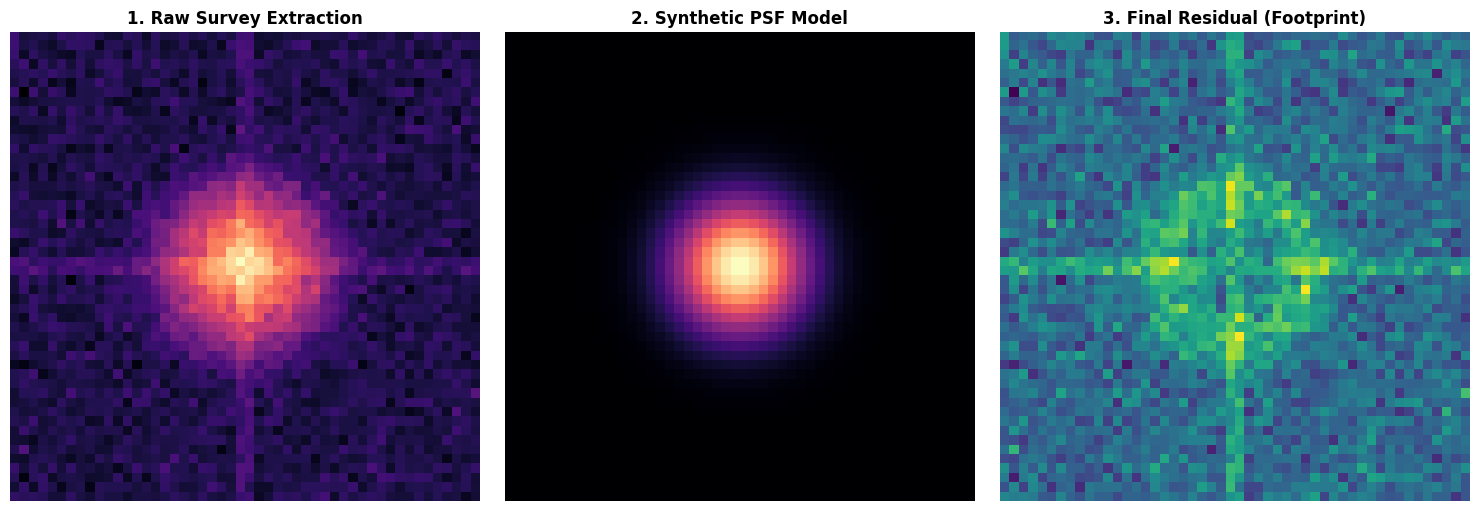


 USER INTERACTIVE LABELING PROMPT 
Please inspect the Three-Panel Image Array above carefully.
Focus on panel #3 (Final Residual) to look for clean structure vs. artifacts.

QUESTION: Is the center of the final residual image symmetric, compact, and completely free of diffraction spikes, cosmic rays, or background galaxy smears? (yes/no): yes

CONFIDENCE SCALE: 100 (Very Sure) | 75 (Sure) | 50 (Undecided) | 25 (Likely No) | 0 (Very Sure No)
QUESTION: Enter your confidence level (100, 75, 50, 25, 0): 0

-> Residual Profiling Metadata Label Generated and Saved: 1 (Confidence: 0%)



In [60]:
import time
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as display

def run_module_6(active_id):
    """
    Generates a simulated Three-Panel Image Vetting Array to vet residual
    disk profiling (Raw Image vs. PSF Model vs. Residual Footprint).
    """
    print("==================================================")
    print("MODULE 6: RESIDUAL DISK PROFILING")
    print("==================================================\n")

    if not active_id:
        print("ERROR: No active target data provided. Please run Module 0 first.")
        return None

    print(f"Generating Three-Panel Extraction Array for {active_id}...")

    # 1. Simulate the image footprint (50x50 pixel grid)
    x = np.linspace(-5, 5, 50)
    y = np.linspace(-5, 5, 50)
    X, Y = np.meshgrid(x, y)
    R = np.sqrt(X**2 + Y**2)

    # Create a synthetic Point Spread Function (PSF - ideal star)
    psf_model = np.exp(-(X**2 + Y**2) / 2.0)

    # Inject background noise, a faint "disk" ring, and a minor diffraction spike
    background_noise = np.random.normal(0, 0.05, (50, 50))
    debris_disk = 0.15 * np.exp(-(R - 1.5)**2 / 0.5) # Ring-like structure

    # Add a mock diffraction spike
    diffraction_spike = np.zeros((50, 50))
    diffraction_spike[24:26, :] = 0.1
    diffraction_spike[:, 24:26] = 0.1

    # Combine to form the "Raw" observed image
    raw_image = psf_model + debris_disk + diffraction_spike + background_noise

    # 2. Calculate the Residual Image (Raw - PSF)
    residual_image = raw_image - psf_model

    # 3. Generate the 3-Panel Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Panel A: Raw Image
    im1 = axes[0].imshow(raw_image, cmap='magma', origin='lower')
    axes[0].set_title("1. Raw Survey Extraction", fontsize=12, fontweight='bold')
    axes[0].axis('off')

    # Panel B: PSF Model
    im2 = axes[1].imshow(psf_model, cmap='magma', origin='lower')
    axes[1].set_title("2. Synthetic PSF Model", fontsize=12, fontweight='bold')
    axes[1].axis('off')

    # Panel C: Final Residual
    im3 = axes[2].imshow(residual_image, cmap='viridis', origin='lower')
    axes[2].set_title("3. Final Residual (Footprint)", fontsize=12, fontweight='bold')
    axes[2].axis('off')

    plt.tight_layout()

    # Force Colab to completely render the plot visual elements right now
    display.display(fig)
    plt.close(fig)

    # 4. Interactive Labeling Prompt
    print("\n" + "="*80)
    print(" USER INTERACTIVE LABELING PROMPT ")
    print("="*80)
    print("Please inspect the Three-Panel Image Array above carefully.")
    print("Focus on panel #3 (Final Residual) to look for clean structure vs. artifacts.\n", flush=True)

    time.sleep(0.5)
    user_input = input("QUESTION: Is the center of the final residual image symmetric, compact, and completely free of diffraction spikes, cosmic rays, or background galaxy smears? (yes/no): ").strip().lower()

    print("\nCONFIDENCE SCALE: 100 (Very Sure) | 75 (Sure) | 50 (Undecided) | 25 (Likely No) | 0 (Very Sure No)")
    confidence_input = input("QUESTION: Enter your confidence level (100, 75, 50, 25, 0): ").strip()

    binary_label = 1 if user_input in ['yes', 'y'] else 0
    print(f"\n-> Residual Profiling Metadata Label Generated and Saved: {binary_label} (Confidence: {confidence_input}%)\n")

    return {'label': binary_label, 'confidence': confidence_input}

# --- EXECUTION BLOCK ---
if __name__ == "__main__":
    module_6_label = run_module_6(active_id=ACTIVE_TARGET_ID)


**Module 7: Machine Learning Dataset Export**
Aggregates the interactive evaluations from all previous modules and merges them with the target's raw photometric metadata. Outputs the results into two specialized dataset files: one optimized for CNNs and another for Random Forests.

In [61]:
import os
import pandas as pd
import numpy as np

def extract_label_data():
    """Safely extracts labels and confidences from the global namespace."""
    # Defaults in case a module was skipped or failed
    data = {
        'mod1_spatial_label': np.nan, 'mod1_conf': np.nan,
        'mod2_sat_label': np.nan, 'mod2_conf': np.nan,
        'mod3b_ir_excess_label': np.nan, 'mod3b_conf': np.nan,
        'mod3_sed_label': np.nan, 'mod3_conf': np.nan,
        'mod4_temp_var_label': np.nan, 'mod4_conf': np.nan,
        'mod5_crowd_label': np.nan, 'mod5_conf': np.nan,
        'mod6_resid_label': np.nan, 'mod6_conf': np.nan,
    }

    # Module 1
    if 'target_package' in globals() and target_package:
        data['mod1_spatial_label'] = target_package.get('spatial_label', np.nan)
        data['mod1_conf'] = float(target_package.get('confidence', np.nan))

    # Module 2
    if 'module_2_package' in globals() and module_2_package:
        data['mod2_sat_label'] = module_2_package.get('saturation_label', np.nan)
        data['mod2_conf'] = float(module_2_package.get('confidence', np.nan))

    # Bonus Module 1 (Returns a tuple)
    if 'module_3_label' in globals() and module_3_label:
        data['mod3b_ir_excess_label'] = module_3_label[0]
        data['mod3b_conf'] = float(module_3_label[1])

    # Module 3 (Returns a tuple)
    if 'module_3_sed_label' in globals() and module_3_sed_label:
        data['mod3_sed_label'] = module_3_sed_label[0]
        data['mod3_conf'] = float(module_3_sed_label[1])

    # Module 4
    if 'module_4_label' in globals() and module_4_label:
        data['mod4_temp_var_label'] = module_4_label.get('label', np.nan)
        data['mod4_conf'] = float(module_4_label.get('confidence', np.nan))

    # Module 5
    if 'module_5_label' in globals() and module_5_label:
        data['mod5_crowd_label'] = module_5_label.get('label', np.nan)
        data['mod5_conf'] = float(module_5_label.get('confidence', np.nan))

    # Module 6
    if 'module_6_label' in globals() and module_6_label:
        data['mod6_resid_label'] = module_6_label.get('label', np.nan)
        data['mod6_conf'] = float(module_6_label.get('confidence', np.nan))

    return data

def build_cnn_row(base_data, labels):
    """
    CNN Tabular formatting:
    - Strict numerical arrays
    - Zero-imputation for missing values
    - Drops strings (except target ID for tracking)
    """
    cnn_data = {**base_data, **labels}

    # Keep only numeric columns + objid
    df_cnn = pd.DataFrame([cnn_data])
    numeric_cols = df_cnn.select_dtypes(include=[np.number]).columns

    df_cnn_final = df_cnn[['objid'] + list(numeric_cols)].copy()

    # Fill NaNs with 0.0 for rigid tensor calculations
    df_cnn_final.fillna(0.0, inplace=True)
    return df_cnn_final

def build_rf_row(base_data, labels):
    """
    Random Forest Tabular formatting:
    - Preserves categorical relationships better
    - -999 imputation for missing values (allows trees to branch on missingness)
    - Add engineered features (e.g. Color Index)
    """
    rf_data = {**base_data, **labels}
    df_rf = pd.DataFrame([rf_data])

    # Engineered Features: Color indices
    if 'i1_f_ap2' in df_rf.columns and 'i2_f_ap2' in df_rf.columns:
        # Simple ratio representation of color (I1/I2)
        df_rf['color_ratio_i1_i2'] = df_rf['i1_f_ap2'] / df_rf['i2_f_ap2'].replace(0, np.nan)

    if 'i3_f_ap2' in df_rf.columns and 'i4_f_ap2' in df_rf.columns:
        df_rf['color_ratio_i3_i4'] = df_rf['i3_f_ap2'] / df_rf['i4_f_ap2'].replace(0, np.nan)

    # Fill NaNs with -999 for tree isolation
    df_rf.fillna(-999, inplace=True)
    return df_rf

def run_module_7(active_id, active_photometry):
    print("==================================================")
    print("MODULE 7: DATASET EXPORT")
    print("==================================================\n")

    if not active_id or not active_photometry:
        print("ERROR: No active target data provided.")
        return

    print(f"Aggregating metadata for target: {active_id}")

    # Collect Labels
    labels = extract_label_data()

    # Generate Datasets
    df_cnn = build_cnn_row(active_photometry, labels)
    df_rf = build_rf_row(active_photometry, labels)

    # File Paths
    cnn_path = 'cnn_dataset.csv'
    rf_path = 'rf_dataset.csv'

    # Append or Create CSVs
    if not os.path.exists(cnn_path):
        df_cnn.to_csv(cnn_path, index=False)
    else:
        df_cnn.to_csv(cnn_path, mode='a', header=False, index=False)

    if not os.path.exists(rf_path):
        df_rf.to_csv(rf_path, index=False)
    else:
        df_rf.to_csv(rf_path, mode='a', header=False, index=False)

    print("\n-> SUCCESS: Exported target data to Machine Learning Datasets!")
    print(f"   1. CNN Format appended to: {cnn_path}")
    print(f"   2. Random Forest Format appended to: {rf_path}")
    print("\nYou can now loop back to Module 0 to fetch the next target in the pipeline.")

# --- EXECUTION BLOCK ---
if __name__ == "__main__":
    run_module_7(
        active_id=ACTIVE_TARGET_ID,
        active_photometry=ACTIVE_PHOTOMETRY
    )


MODULE 7: DATASET EXPORT

Aggregating metadata for target: SSTSL2 J152742.67+023551.8

-> SUCCESS: Exported target data to Machine Learning Datasets!
   1. CNN Format appended to: cnn_dataset.csv
   2. Random Forest Format appended to: rf_dataset.csv

You can now loop back to Module 0 to fetch the next target in the pipeline.


**Bonus Module 2: MLM CSV Files Viewer**

If you want to see the dataset saved at CNN and Rain Forest, run this module.

In [63]:
import pandas as pd
from IPython.display import display

# Display the first few rows of the CNN dataset
print("--- CNN Dataset (cnn_dataset.csv) ---")
cnn_df = pd.read_csv('/content/cnn_dataset.csv')
display(cnn_df.head())

# Display the first few rows of the Random Forest dataset
print("\n--- Random Forest Dataset (rf_dataset.csv) ---")
rf_df = pd.read_csv('/content/rf_dataset.csv')
display(rf_df.head())


--- CNN Dataset (cnn_dataset.csv) ---


,objid,crowded,badbkgmatch,ra,dec,l,b,nmatches,nreject,nbands,...,mod3b_ir_excess_label,mod3b_conf,mod3_sed_label,mod3_conf,mod4_temp_var_label,mod4_conf,mod5_crowd_label,mod5_conf,mod6_resid_label,mod6_conf
0,SSTSL2 J152742.67+023551.8,0,0,231.927823,2.597747,6.474539,45.311356,1,0,7,...,0,25.0,1,75.0,0,50.0,1,75.0,1,0.0



--- Random Forest Dataset (rf_dataset.csv) ---


,objid,crowded,badbkgmatch,ra,dec,l,b,nmatches,nreject,nbands,...,mod3_sed_label,mod3_conf,mod4_temp_var_label,mod4_conf,mod5_crowd_label,mod5_conf,mod6_resid_label,mod6_conf,color_ratio_i1_i2,color_ratio_i3_i4
0,SSTSL2 J152742.67+023551.8,0,0,231.927823,2.597747,6.474539,45.311356,1,0,7,...,1,75.0,0,50.0,1,75.0,1,0.0,1.61584,1.742128
